In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["transformer"])
df = qm9.load()

2026-05-07 08:25:57.117 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-07 08:25:57.830 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-07 08:25:57.833 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-07 08:25:57.833 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-05-07 08:26:45.943 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['selfies_transformer']


In [4]:
len(df['selfies_transformer'].to_list()[0])

768

In [5]:
molecules = qm9.get_molecules()

2026-05-07 08:26:49.728 | SUCCESS  | src.datasets:get_molecules:1689 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="transformer",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=8,
)

2026-05-07 08:26:51.261 | INFO     | src.datasets:get_distance_matrix:1479 - Applying PCA to reduce 'selfies_transformer' to 8 dimensions.
2026-05-07 08:26:51.399 | INFO     | src.datasets:get_distance_matrix:1483 - PCA kept 62.16% of the variance for 'selfies_transformer'.
2026-05-07 08:26:51.400 | INFO     | src.datasets:get_distance_matrix:1485 - PCA reduced 'selfies_transformer' dimensions from 768 to 8
2026-05-07 08:26:51.442 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for selfies_transformer using euclidean distance.
2026-05-07 08:26:52.283 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_selfies_transformer_euclidean_pca8.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:10<00:00,  1.07s/it]


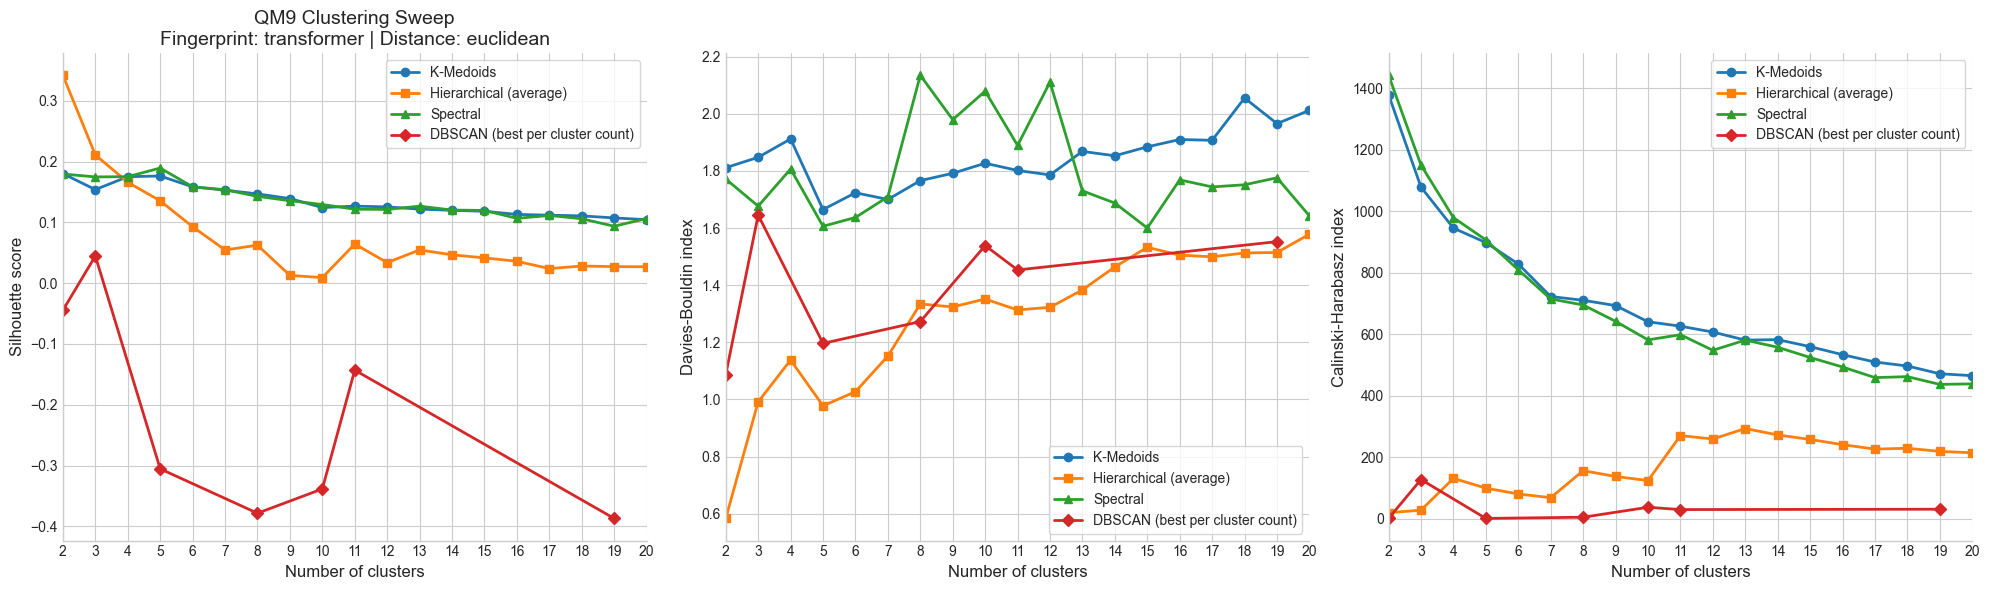

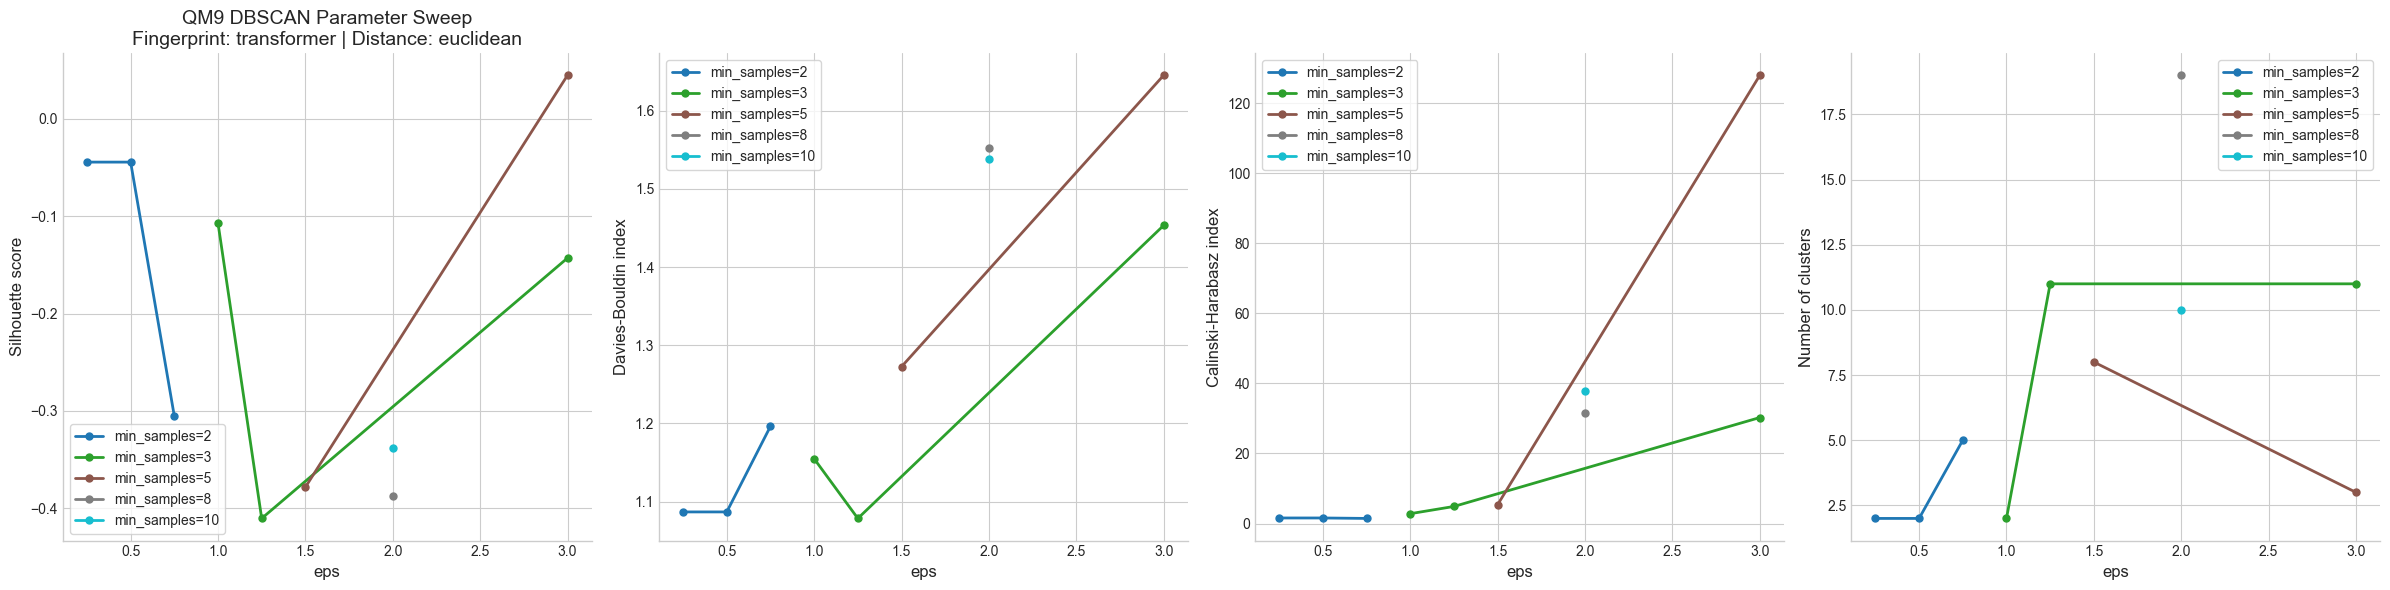

2026-05-07 08:30:18.756 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1059 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.png
2026-05-07 08:30:18.758 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1061 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/transformer/dbscan_parameter_sweep.png
2026-05-07 08:30:18.758 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:1062 - Saved clustering sweep results to figures/qm9/clustering/euclidean/transformer/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4856), np.int64(4857)), (np.int64(848), np.int64(849)), (np.int64(4204), np.int64(4520)), (np.int64(2132), np.int64(2133)), (np.int64(2352), np.int64(2353)), (np.int64(2339), np.int64(2340)), (np.int64(3320), np.int64(3321)), (np.int64(1483), np.int64(3016)), (np.int64(2588), np.int64(3514)), (np.int64(3190), np.int64(3191))]


In [10]:
print(mols[0])

(Atoms(symbols='NC2OCN2COH5', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='NC2ON2C2OH5', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [11]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

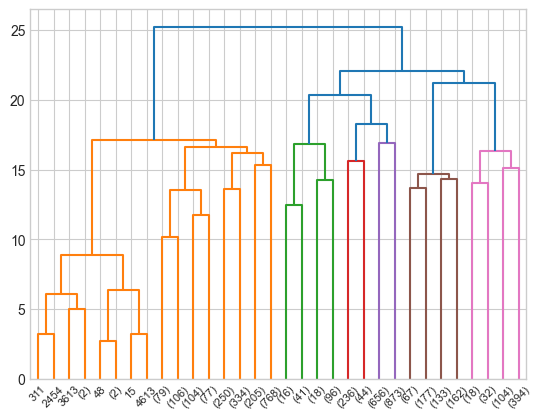

In [12]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [37]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2]), array([1087, 1933, 1980]))


In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-05-07 08:30:31.007 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:30:31.014 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:32:22.103 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:32:22.409 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:32:23.281 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:32:23.406 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

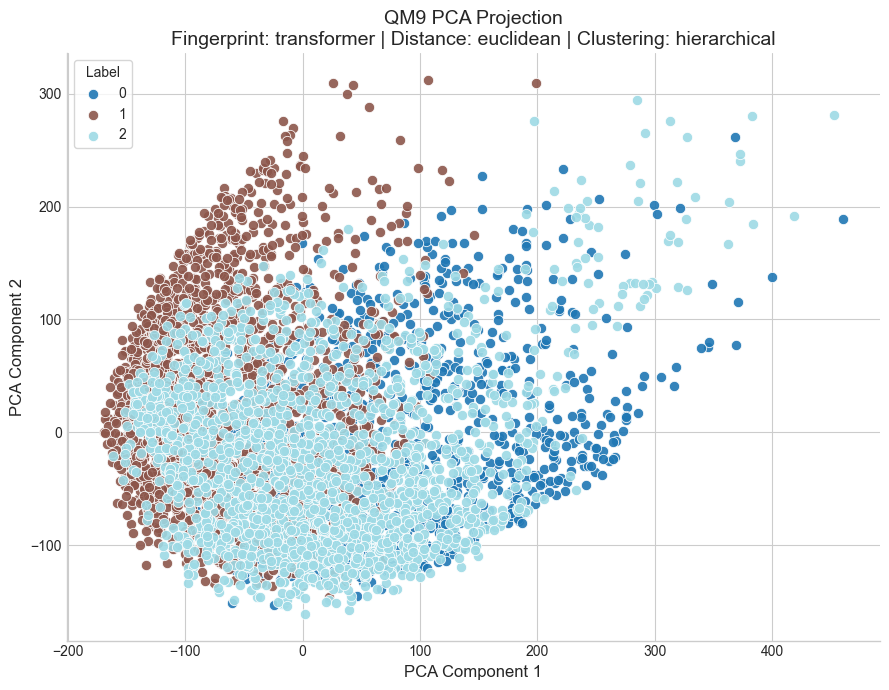

2026-05-07 08:45:04.258 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png


{'coords': array([[  67.23140169,   96.32532045],
        [ 244.06019512,  183.95995627],
        [ -65.53741276,   10.12647242],
        ...,
        [  64.99383654, -117.89164667],
        [ 264.55125782,  -23.77311609],
        [ 177.59666744,  -71.11911393]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'hierarchical'}

In [ ]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [16]:
average_numeric_by_cluster(df, "labels_hier")

shape: (6, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1933,0.765027,0.0,122.790998,0.190378,34.029488,0.863633,12.845797,8.788929,1.884118,0.232799,0.013451,2.378169,18.466632,2.085191,2.082773,0.037339,0.235443,0.727218,0.85463,2.057941,6.697879,0.24418,1.324366,4.842214,6.282462,13.828246,1.26592,0.001035,0.349715,0.049664,0.086394,0.071909,0.0,0.028971,0.080704,0.617693,0.0,2.49753,75.339974,-6.4316,0.567047,6.998666,1145.046023,4.145365,-11143.566235,-11143.340506,-11143.314833,-11144.465533,31.330964,-76.913607,-77.392153,-77.836111,-71.556269,3.359955,1.447808,1.155072,77.133989,21.883083,0.982928,13.828246,817,"""C1CC2CC12""",3.05225,197,"""C1CCCC1""",13.657527,1,null,0.0
1,1529,0.771554,0.0,122.592544,0.018313,37.877698,0.865727,12.846669,8.773708,1.559189,0.200131,0.028123,2.536952,17.895356,2.049656,2.308698,0.069819,0.276155,0.654026,0.961413,2.10726,6.425768,0.448005,1.580772,4.207979,6.311969,13.548071,1.261289,0.00654,0.353826,0.032701,0.12361,0.173316,0.001308,0.055592,0.165468,0.433617,0.001962,2.826093,74.358123,-6.521832,0.060887,6.582783,1182.054248,3.95032,-11250.31312,-11250.082133,-11250.056424,-11251.224148,31.46351,-75.121537,-75.57233,-76.001292,-69.944731,3.390941,1.417036,1.118816,63.636364,19.686069,16.677567,13.548071,561,"""Acyclic""",16.677567,178,"""Acyclic""",16.677567,1,null,0.0
2,548,0.798827,0.0,123.288321,0.129562,40.656934,0.861941,12.859607,8.817518,1.518248,0.133212,0.051095,2.582117,17.937956,2.051744,2.113139,0.060926,0.242821,0.696253,0.919708,2.191606,6.514599,0.370438,1.421533,4.443431,6.091241,14.089416,1.265346,0.012774,0.355839,0.009124,0.124088,0.268248,0.001825,0.034672,0.213504,0.39781,0.00365,3.104027,74.535493,-6.609308,0.024883,6.634106,1177.817516,4.010407,-11337.937019,-11337.702682,-11337.676959,-11338.850432,31.959168,-75.91426,-76.370138,-76.804725,-70.671246,3.152714,1.398385,1.098991,74.087591,13.321168,12.591241,14.089416,266,"""Acyclic""",12.591241,105,"""Acyclic""",12.591241,1,null,0.0
3,539,0.784495,0.0,123.851577,-0.604824,43.044527,0.749443,12.958087,8.818182,1.946197,0.116883,0.037106,2.987013,18.294991,2.091829,2.296846,0.052469,0.22225,0.725281,1.213358,1.734694,6.584416,0.326531,1.077922,4.426716,6.371058,14.044527,1.262484,0.0,0.213358,0.012987,0.380334,0.087199,0.009276,0.029685,0.072356,0.617811,0.0,2.84254,73.373154,-6.484625,0.051434,6.536089,1120.878871,3.73612,-11338.63405,-11338.41571,-11338.390054,-11339.529363,30.052544,-71.966066,-72.402515,-72.813447,-66.965473,3.408508,1.518468,1.208249,80.519481,10.575139,8.90538,14.044527,304,"""Acyclic""",8.90538,113,"""C1CCCC1""",12.801484,1,null,0.0
4,171,0.599252,0.0,118.374269,0.28655,27.97076,0.917407,12.727128,8.590643,0.210526,0.0,0.0,1.654971,18.438596,1.909486,3.497076,0.355521,0.055737,0.588743,0.666667,1.502924,4.701754,2.491228,0.356725,4.087719,7.824561,10.719298,1.237087,0.0,0.426901,0.0,0.087719,0.02924,0.0,0.0,0.076023,0.327485,0.0,2.4

# KMedoids

In [17]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2], dtype=uint64), array([1518, 1294, 2188]))


In [18]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-05-07 08:32:25.907 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:32:25.909 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:34:21.335 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:34:21.395 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:34:22.147 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:34:22.300 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

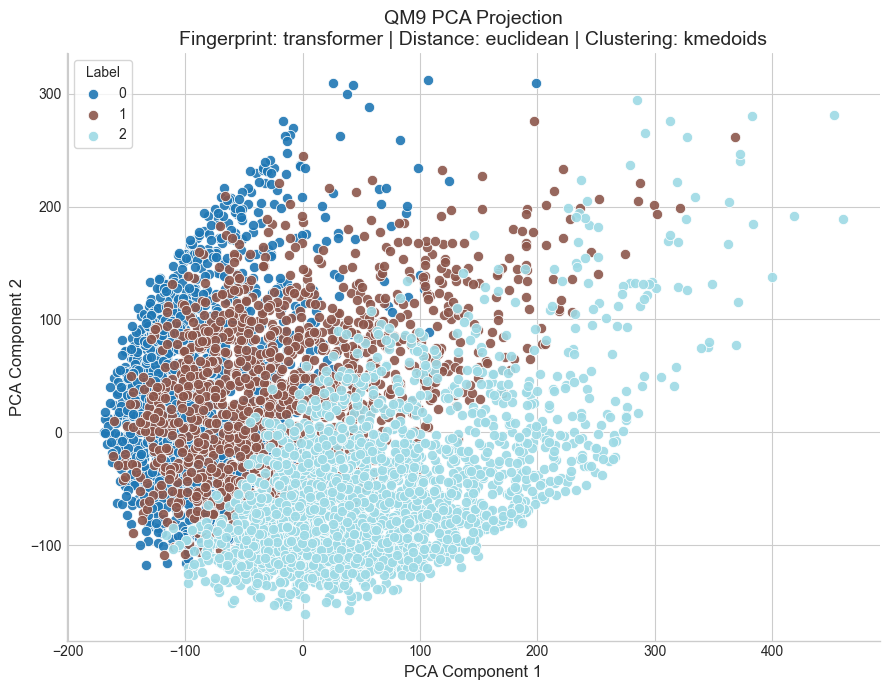

2026-05-07 08:34:24.149 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png


{'coords': array([[  67.23140169,   96.32532045],
        [ 244.06019512,  183.95995627],
        [ -65.53741276,   10.12647242],
        ...,
        [  64.99383654, -117.89164667],
        [ 264.55125782,  -23.77311609],
        [ 177.59666744,  -71.11911393]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'kmedoids'}

In [19]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [20]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1518,0.744022,0.0,123.254941,0.381423,28.28722,0.945696,12.7935,8.801713,1.965744,0.06917,0.003294,1.95191,19.405138,2.090269,2.311594,0.029013,0.142925,0.828062,0.70751,1.855072,6.901186,0.206192,0.921607,5.722003,6.261528,14.190382,1.266596,0.0,0.464427,0.017787,0.023057,0.057312,0.0,0.033597,0.108037,0.731225,0.0,2.215435,76.849289,-6.522193,0.842366,7.364588,1160.764646,4.472688,-11048.695342,-11048.462439,-11048.436752,-11049.599587,32.541003,-80.683171,-81.196136,-81.667847,-75.022476,3.124214,1.448002,1.174406,0.503294,91.765481,6.455863,1.778656,14.190382,606,"""C1CC1""",4.611331,173,"""C1CC2CC12""",10.408432,1,null,0.0
1,1294,0.79578,0.0,122.666151,-0.482226,35.307573,0.801962,12.877429,8.806028,2.412674,0.082689,0.010046,2.53323,18.420402,2.134777,1.746522,0.04929,0.161974,0.788736,1.170015,1.666924,6.8949,0.319165,0.873261,5.080371,6.166924,14.395672,1.269792,0.0,0.284389,0.006182,0.197063,0.069552,0.000773,0.01932,0.090417,0.520093,0.0,2.694275,74.122233,-6.424856,0.374371,6.799286,1074.843569,3.905512,-11057.692851,-11057.481265,-11057.455594,-11058.575139,29.795084,-73.9719,-74.434147,-74.857787,-68.822084,3.354466,1.564684,1.266897,1.458269,90.57187,7.496136,1.931994,14.395672,717,"""C1C[NH+]2CC12""",3.400309,222,"""C1CC2CC12""",6.723338,1,null,0.0
2,2188,0.755361,0.0,122.344607,0.172303,42.560786,0.828988,12.880029,8.748629,1.021938,0.310786,0.045247,2.75457,17.472121,2.001225,2.578154,0.100781,0.331957,0.567262,0.912706,2.32404,5.999543,0.653565,1.807587,3.532907,6.537934,12.875229,1.255763,0.008684,0.298446,0.056216,0.165448,0.202468,0.003199,0.047532,0.144881,0.390311,0.002285,3.010744,74.620973,-6.576084,-0.106846,6.469236,1275.649073,3.853509,-11320.604016,-11320.363193,-11320.337489,-11321.533459,32.040886,-74.054393,-74.484356,-74.905988,-68.978409,3.736317,1.281751,0.995713,1.679616,48.126143,30.11883,21.755027,12.875229,555,"""Acyclic""",21.755027,127,"""Acyclic""",21.755027,1,null,0.0


# Spectral

In [21]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))

model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)

In [22]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-05-07 08:34:29.719 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:34:29.728 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:36:24.234 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:36:24.248 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:36:24.784 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:36:24.945 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

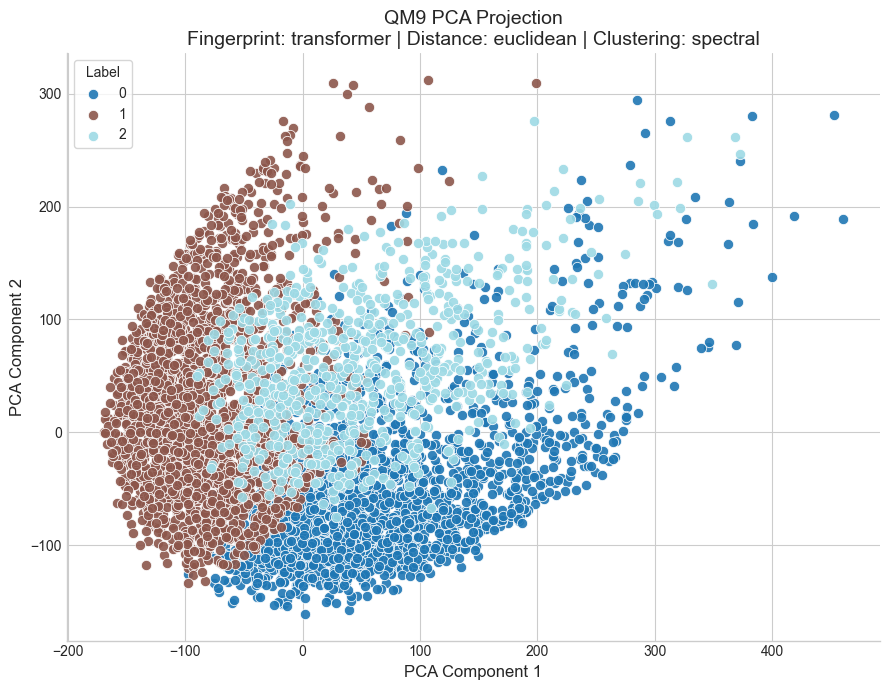

2026-05-07 08:36:26.499 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png


{'coords': array([[  67.23140169,   96.32532045],
        [ 244.06019512,  183.95995627],
        [ -65.53741276,   10.12647242],
        ...,
        [  64.99383654, -117.89164667],
        [ 264.55125782,  -23.77311609],
        [ 177.59666744,  -71.11911393]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'spectral'}

In [23]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [24]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2141,0.762119,0.0,122.144792,0.170948,43.360579,0.815299,12.887565,8.738907,1.025222,0.362447,0.04624,2.819243,17.281177,2.002314,2.522186,0.095611,0.362438,0.541951,0.935544,2.376927,6.002335,0.617001,1.953293,3.349369,6.514713,12.844932,1.255703,0.008874,0.285848,0.064456,0.178888,0.200374,0.00327,0.044372,0.137319,0.360579,0.002335,3.017263,74.354661,-6.534614,-0.153375,6.381228,1263.715847,3.799755,-11328.151424,-11327.91266,-11327.886963,-11329.078069,31.780056,-73.424109,-73.84901,-74.265887,-68.399086,3.779463,1.29877,1.00174,1.56936,1.909388,44.558617,34.70341,20.737973,12.844932,563,"""Acyclic""",20.737973,115,"""C1CCCC1""",22.41943,1,null,0.0
1,2128,0.756358,0.0,123.204887,0.211936,29.089286,0.927985,12.797376,8.815789,2.111372,0.030545,0.00188,2.008929,19.256579,2.104544,2.121711,0.037186,0.121476,0.841338,0.795113,1.800282,6.925282,0.258929,0.799342,5.74859,6.217575,14.31203,1.268885,0.0,0.442199,0.007989,0.027256,0.070019,0.0,0.031955,0.117951,0.68515,0.0,2.349036,76.44742,-6.527323,0.78545,7.312818,1143.8723,4.389441,-11037.071986,-11036.843342,-11036.81765,-11037.971683,32.062107,-79.744733,-80.251439,-80.716129,-74.156199,3.122869,1.463979,1.194624,0.616541,0.370301,95.629699,3.007519,1.362782,14.31203,859,"""C1CC1""",3.806391,243,"""C1CC2CC12""",10.009398,1,null,0.0
2,731,0.780667,0.0,122.885089,-0.663475,36.954856,0.775411,12.914276,8.793434,2.262654,0.069767,0.019152,2.677155,18.529412,2.118586,2.045144,0.060873,0.161963,0.777163,1.21751,1.556772,6.753762,0.388509,0.822161,4.905609,6.307798,14.20383,1.265071,0.0,0.236662,0.004104,0.288646,0.057456,0.001368,0.023256,0.072503,0.556772,0.0,2.706188,73.828509,-6.459879,0.254868,6.714806,1100.181392,3.828651,-11093.836229,-11093.62212,-11093.596453,-11094.724655,29.806125,-72.95471,-73.405607,-73.823369,-67.876637,3.448703,1.547504,1.250134,2.262654,1.086183,86.046512,6.429549,7.52394,14.20383,397,"""Acyclic""",7.52394,145,"""C1CCCC1""",8.618331,1,null,0.0


# DBSCAN 

In [25]:
model_db = DBSCAN(
    eps=2,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]), array([2629,    4, 1492,    4,  272,    4,   12,   11,   12,    6,    4,
          3,    8,    7,    3,    3,    3,   11,    5,    4,    8,    5,
          4,   15,    5,    7,    3,    6,    4,    4,    3,    3,   

In [26]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-07 08:36:27.229 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:36:27.235 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:38:19.895 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:38:19.955 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:38:20.560 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:38:20.707 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

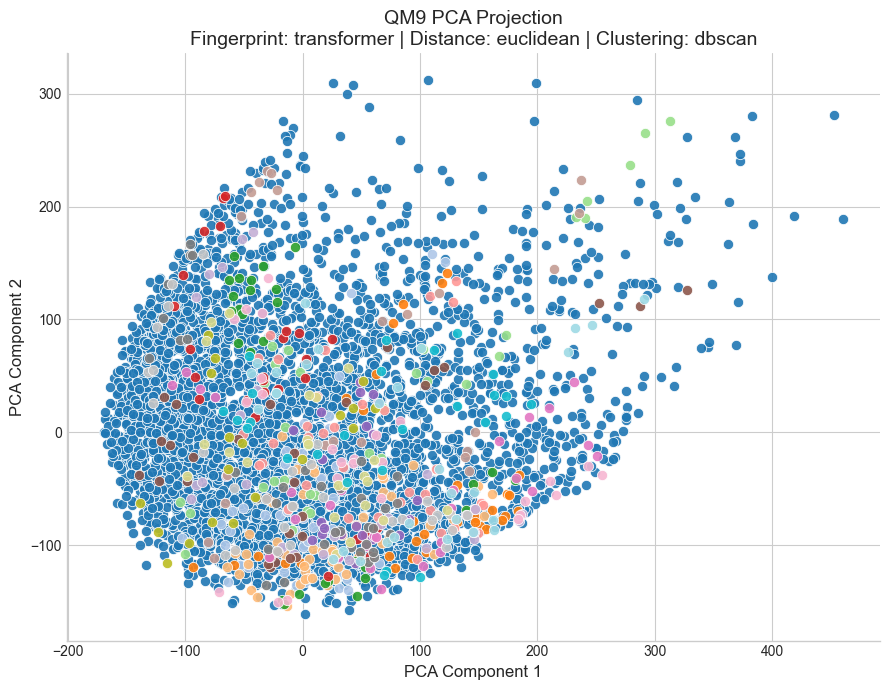

2026-05-07 08:38:24.513 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png


{'coords': array([[  67.23140169,   96.32532045],
        [ 244.06019512,  183.95995627],
        [ -65.53741276,   10.12647242],
        ...,
        [  64.99383654, -117.89164667],
        [ 264.55125782,  -23.77311609],
        [ 177.59666744,  -71.11911393]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/transformer/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/transformer'),
 'clustering_method': 'dbscan'}

In [27]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [28]:
average_numeric_by_cluster(df, "labels_db")

shape: (141, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2629,0.751627,0.0,122.213389,0.057056,38.344618,0.833363,12.872763,8.740205,1.446177,0.186763,0.026246,2.551541,18.144542,2.042861,2.384937,0.080151,0.244614,0.675234,0.927729,2.049448,6.337771,0.518828,1.339293,4.330544,6.42906,13.309243,1.259856,0.004564,0.31647,0.027387,0.148726,0.139597,0.001521,0.032712,0.114492,0.478129,0.001902,2.771542,74.983625,-6.56895,0.180365,6.749293,1216.457014,3.994129,-11144.483621,-11144.250046,-11144.224354,-11145.399448,31.651025,-75.193104,-75.646186,-76.078397,-69.987505,3.618946,1.365763,1.089269,1.471282,1.256371,0.686573,68.048688,17.611259,14.340053,13.309243,925,"""Acyclic""",14.340053,223,"""Acyclic""",14.340053,1,null,0.0
0,4,0.771384,0.0,107.25,-0.25,44.5,0.814398,12.976696,7.5,0.0,0.0,0.0,3.25,14.25,1.856086,2.25,0.125,0.475,0.4,0.75,2.0,5.0,0.5,2.0,1.75,6.0,11.0,1.236872,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,3.10835,60.559999,-6.891283,-1.619758,5.272206,985.551132,3.039376,-10471.074341,-10470.844482,-10470.819092,-10471.988647,28.17625,-60.417073,-60.736309,-61.076847,-56.366801,5.224013,1.768293,1.31411,1.0,2.0,0.0,0.0,0.0,100.0,11.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
1,1492,0.778974,0.0,123.654826,0.065013,29.103887,0.93537,12.792319,8.849866,2.280831,0.002681,0.006032,2.050268,19.113941,2.118029,1.99866,0.037035,0.115996,0.84697,0.845845,1.757373,6.955094,0.254692,0.774129,5.770777,6.121314,14.662869,1.270843,0.0,0.463807,0.0,0.040885,0.08378,0.00134,0.043566,0.14008,0.689678,0.0,2.417991,75.807487,-6.515278,0.679955,7.195331,1113.440283,4.311927,-11123.614008,-11123.389713,-11123.364036,-11124.507218,31.673074,-79.087462,-79.589438,-80.048069,-73.556735,3.046417,1.510379,1.230663,0.878686,0.628686,1.008713,95.77748,0.268097,3.954424,14.662869,710,"""Acyclic""",3.954424,225,"""C1CC2CC12""",9.24933,1,null,0.0
2,4,0.751394,0.0,118.25,-1.0,20.5,0.805898,12.88313,8.5,2.75,0.0,0.0,2.0,19.25,2.179991,1.25,0.0,0.071429,0.928571,1.5,1.0,7.75,0.0,0.5,6.0,6.0,14.5,1.269824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,1.834975,73.229999,-6.136168,0.19184,6.327328,1007.393356,4.044462,-10282.687988,-10282.48999,-10282.464355,-10283.550293,28.53625,-74.069942,-74.556252,-74.986772,-68.861489,4.489043,1.594282,1.381353,0.0,1.0,1.5,100.0,0.0,0.0,14.5,4,"""C1C[NH+]2CC12""",25.0,4,"""C1C2C1C1CC21""",25.0,1,null,0.0
3,272,0.799388,0.0,122.033088,0.191176,50.341912,0.698304,12.966886,8.764706,1.150735,0.9375,0.069853,3.430147,15.977941,2.019616,2.330882,0.033675,0.637443,0.328882,1.1875,2.911765,6.143382,0.198529,3.345588,1.790441,6.477941,12.584559,1.255074,0.011029,0.121324,0.224265,0.327206,0.080882,0.0,0.014706,0.051471,0.231618,0.0,2.989243,72.63136,-6.036256,-0.127683,5.908652,1178.282162,3.436072,-11520.2343,-11520.010577,-11519.984917,-11521.14093,29.931279,-69.380639,-69.772688,-70.157626,-64.684459,3.835152,1

# HDBSCAN

In [29]:
from src.helper_functions import evaluate_hdbscan_grid
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=10, ms=1, clusters=4, noise=0.24, persistence=0.032, score=0.024
mcs=10, ms=1, clusters=4, noise=0.24, persistence=0.032, score=0.024


In [30]:
from hdbscan import HDBSCAN
clusterer = HDBSCAN(
        min_cluster_size=10,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [31]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-07 08:39:52.371 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...
2026-05-07 08:39:52.373 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:41:38.220 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:41:38.279 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:41:39.577 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-07 08:41:39.844 | WARNING  | src.helper_functions:create_chemiscope_viewer:1348 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

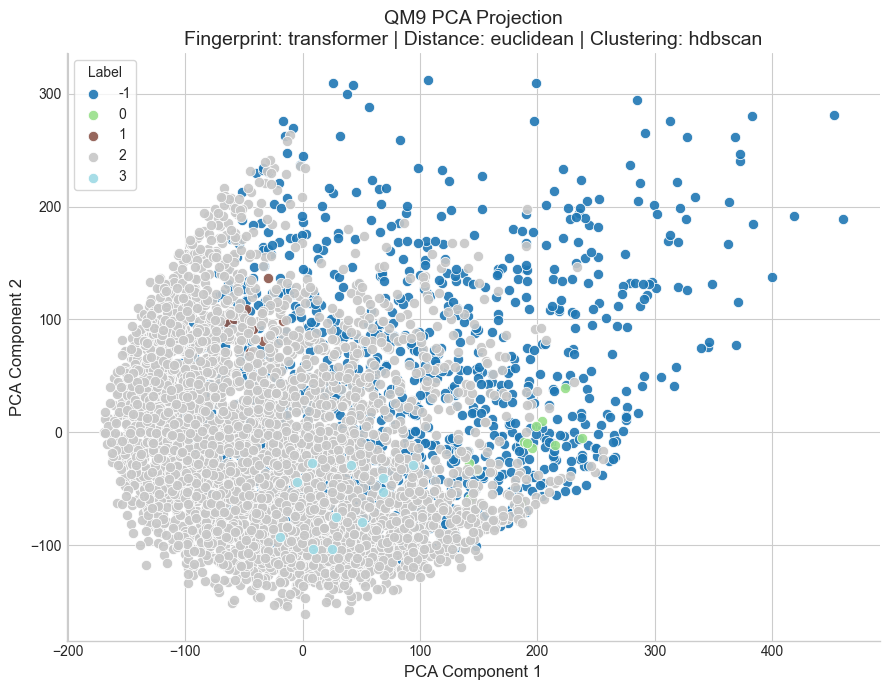

2026-05-07 08:41:46.443 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/euclidean/transformer/pca_hdbscan_projection.png


In [32]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="transformer",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [33]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (5, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,1187,0.734561,0.0,121.271272,0.085931,37.925021,0.813181,12.879476,8.689975,1.269587,0.180286,0.034541,2.518113,18.066554,2.024383,2.487784,0.110625,0.238161,0.651213,0.871104,1.973041,6.151643,0.718618,1.265375,4.187869,6.564448,12.882056,1.257065,0.005055,0.249368,0.021061,0.155855,0.131424,0.001685,0.017692,0.117102,0.4246,0.001685,2.818018,75.39064,-6.633327,0.112121,6.745405,1267.200631,3.957031,-11006.460559,-11006.223593,-11006.197877,-11007.384181,31.760975,-74.681245,-75.126165,-75.555216,-69.524577,3.943722,1.321871,1.05619,1.800337,1.360573,0.671441,2.280539,62.257793,16.680708,21.0615,12.882056,471,"""Acyclic""",21.0615,138,"""Acyclic""",21.0615,1,null,0.0
0,12,0.674532,0.0,125.583333,-0.083333,44.75,0.952289,12.806188,8.916667,0.0,0.0,0.0,2.75,17.666667,1.885112,3.75,0.264683,0.203968,0.531349,0.75,2.5,4.916667,1.666667,1.25,3.25,7.916667,11.75,1.241335,0.0,0.5,0.0,0.166667,0.25,0.0,0.333333,0.333333,0.416667,0.0,2.971808,75.925833,-6.900127,-0.465995,6.434359,1781.73586,3.830896,-11837.21875,-11836.932048,-11836.906494,-11838.242269,35.458584,-75.197153,-75.591593,-76.019952,-70.123192,4.594988,0.738724,0.652789,2.0,2.0,0.0,-1.0,0.0,0.0,100.0,11.75,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
1,11,0.582545,0.0,124.363636,1.0,17.0,0.929137,12.835682,8.818182,1.090909,0.0,0.0,1.272727,22.818182,2.009569,4.272727,0.063131,0.015152,0.921717,0.454545,1.090909,7.272727,0.545455,0.090909,6.909091,7.363636,13.181818,1.245969,0.0,0.181818,0.0,0.090909,0.090909,0.0,0.0,0.0,0.727273,0.0,1.548691,84.763637,-6.680148,1.802878,8.482778,1494.645724,5.496158,-10499.159979,-10498.88157,-10498.855824,-10500.131037,37.581637,-91.334921,-91.932254,-92.490752,-84.768649,3.109383,1.064103,0.880631,0.0,0.0,1.0,41.0,100.0,0.0,0.0,13.181818,8,"""C1CC1""",18.181818,4,"""C1CC1""",54.545455,1,null,0.0
2,3779,0.771795,0.0,123.138132,0.05901,35.838052,0.87119,12.844709,8.807092,1.802858,0.178883,0.020111,2.433448,18.371262,2.075829,2.206404,0.05093,0.228172,0.720898,0.932786,2.025668,6.619476,0.336862,1.306695,4.730087,6.284731,13.922731,1.264592,0.00344,0.375761,0.035194,0.12199,0.120402,0.001588,0.041016,0.119873,0.560466,0.000794,2.645989,75.064477,-6.484048,0.369,6.853089,1161.366631,4.083737,-11220.239839,-11220.01122,-11219.985537,-11221.14448,31.537277,-76.446899,-76.91627,-77.356034,-71.139657,3.29411,1.434908,1.142831,1.094469,1.061127,0.732998,9.251125,75.681397,17.306166,7.012437,13.922731,1282,"""Acyclic""",7.012437,285,"""C1CCCC1""",13.231013,1,null,0.0
3,11,0.805014,0.0,123.454545,-0.272727,52.545455,0.728366,12.951704,8.818182,0.909091,0.181818,0.0,3.272727,17.181818,1.989305,2.454545,0.062338,0.482035,0.455628,1.090909,1.727273,6.272727,0.363636,2.545455,2.636364,6.545455,13.545455,1.252822,0.0,0.181818,0.0,0.272727,0.454545,0.0,0.0,0.18181

# KMeans on Raw Embeddings


In [34]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_raw = np.array(df["selfies_transformer"].to_list(), dtype=np.float32)
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_raw)

kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_pca)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [35]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans_raw,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2039,0.760705,0.0,122.557626,0.170672,41.952918,0.843997,12.871329,8.760177,1.102992,0.28102,0.045611,2.703776,17.580186,2.009363,2.530162,0.091262,0.319785,0.588953,0.922511,2.297695,6.099068,0.596861,1.76459,3.694949,6.471309,13.07847,1.257198,0.009318,0.323198,0.050025,0.156449,0.209416,0.002943,0.049534,0.158901,…,2.981734,74.663556,-6.577558,-0.082291,6.495254,1263.187204,3.891553,-11333.505577,-11333.265124,-11333.239421,-11334.433402,32.111165,-74.531707,-74.966925,-75.391816,-69.416918,3.653874,1.296536,1.010025,1.699362,1.897989,0.100049,11.171162,1.195194,52.378617,27.219225,20.402158,13.07847,556,"""Acyclic""",20.402158,140,"""Acyclic""",20.402158,1,null,0.0
1,1081,0.79015,0.0,122.650324,-0.565217,36.358002,0.789463,12.89345,8.792784,2.309898,0.075856,0.012951,2.607771,18.414431,2.123853,1.905643,0.058937,0.162117,0.778947,1.192414,1.633673,6.783534,0.382054,0.845513,4.957447,6.242368,14.283071,1.267296,0.0,0.271045,0.004625,0.233117,0.070305,0.00185,0.020352,0.085106,…,2.713539,73.958409,-6.441509,0.328717,6.770263,1091.039034,3.86387,-11071.752856,-11071.539285,-11071.513603,-11072.638901,29.873051,-73.418113,-73.873543,-74.293968,-68.30867,3.400772,1.556375,1.254697,1.827012,1.076781,1.606846,5.387604,1.122109,87.789084,6.93802,5.272895,14.283071,588,"""Acyclic""",5.272895,193,"""C1CCCC1""",7.493062,1,null,0.0
2,1880,0.748226,0.0,122.894149,0.316489,30.269149,0.911071,12.81009,8.793085,1.912766,0.126064,0.005319,2.093617,19.026596,2.085709,2.229255,0.041776,0.173184,0.78504,0.75266,1.918617,6.785106,0.279787,1.048936,5.370745,6.301596,13.953723,1.265979,0.0,0.411702,0.027128,0.043085,0.062234,0.0,0.030319,0.096809,…,2.353106,76.411729,-6.504262,0.713733,7.218049,1164.338605,4.342038,-11049.187743,-11048.957367,-11048.931686,-11050.091091,32.069205,-79.198176,-79.697037,-80.157648,-73.660579,3.261603,1.436788,1.162215,0.471277,0.338298,0.877128,5.105319,1.470745,85.159574,11.914894,2.925532,13.953723,742,"""C1CC1""",4.042553,194,"""C1CC2CC12""",9.521277,1,null,0.0


In [36]:

create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

2026-05-07 08:41:49.554 | INFO     | src.helper_functions:create_chemiscope_viewer:1139 - Running PCA dimensionality reduction...


2026-05-07 08:41:49.696 | INFO     | src.helper_functions:create_chemiscope_viewer:1148 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-07 08:43:52.406 | INFO     | src.helper_functions:create_chemiscope_viewer:1216 - Assembling properties for Chemiscope...
2026-05-07 08:43:52.436 | INFO     | src.helper_functions:create_chemiscope_viewer:1311 - Generating Chemiscope widget...
2026-05-07 08:43:52.974 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1342 - Saved Chemiscope input to: qm9_PCA_clustering.json


JSONDecodeError: Extra data: line 471168 column 7 (char 10698195)